# Autonomous Farming: Corn Row Alignment Scoring
We built a machine learning system that looks at top-down photos of a corn field, finds every individual corn plant, measures *where* each plant is and *which way it's leaning (growing)*, and then scores how well each plant is aligned with the row it was planted in. The output is two numbers per plant (a positional error in pixels and an angular error in degrees) rolled up into a 0-100 alignment score, with per-row averages.

## The five deliverables, mapped to sections of this notebook
| # | Deliverable | Where in notebook |
|---|-------------|-------------------|
| 1 | Detect individual corn plants in an image | Section 4 Training, Section 5 Evaluation |
| 2 | Estimate position and orientation of each plant | Section 6 Inference |
| 3 | Define the optimal growth line per row | Section 8 Optimal line |
| 4 | Compute the deviation from that line | Section 9 Scoring |
| 5 | Produce row-level and plant-level alignment scores | Section 9 Scoring, Section 10 Batch export |

## How it works, at a system level
1. **Camera -> pixels.** A top-down image of the field.
2. **Detection model -> list of plants.** A neural network (YOLO11-pose) returns, for each plant it finds, its class (corn or weed), a bounding box, and three landmark points: the stem center and the two leaf tips. Weeds are detected so the system can ignore them; only corn enters the scoring.
3. **Post-processing -> measurements.** We take those three points and compute (a) the plant's position = stem location, and (b) the plant's orientation = direction of the line through the two leaf tips.
4. **Row fitting -> reference lines.** We group plants by row and either use a known reference line (if we know exactly where the seeds were planted) or we fit a constrained near-vertical line through the detected stems.
5. **Scoring -> numbers.** For each plant: how far is it from its row's reference line? How rotated is its leaf axis from the expected orientation? We combine these into a single 0-100 score.

---
# 1. Setup

Before doing anything interesting, we need to:

1. Confirm the GPU is working. Training on a CPU would take days.
2. Set the project folder so all outputs land in one place.
3. Import the libraries we'll use throughout.

## Before running this notebook, install these packages (once, from your terminal):

```
pip install ultralytics scikit-learn matplotlib opencv-python
```

If you see a CUDA / GPU-related error later, you may also need the GPU build of PyTorch:

```
pip uninstall torch torchvision -y
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121

In [1]:
import torch  # PyTorch - the deep learning framework YOLO is built on
import pandas as pd
print(pd.__version__)
# torch.cuda.is_available() returns True if an NVIDIA GPU + compatible drivers are installed.
# The `assert` line crashes loudly if this returns False, so you find out NOW, not 3 hours into training.
assert torch.cuda.is_available(), "No GPU detected. Check CUDA install / PyTorch version."

# Print GPU model name (useful to confirm you're using the right one if you have multiple).
print(f"GPU:  {torch.cuda.get_device_name(0)}")
print(f"CUDA: {torch.version.cuda}")

3.0.3
GPU:  NVIDIA RTX 1000 Ada Generation Laptop GPU
CUDA: 12.8


In [2]:
import os
from pathlib import Path
PROJECT_ROOT = Path(r"C:\Users\atpou\projects\T1_Corn_Alignment")

# Create the folder if it doesn't already exist. exist_ok=True means "don't error if it's already there".
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)

# Change the working directory so relative paths in later cells resolve here.
os.chdir(PROJECT_ROOT)

print(f"Working from: {PROJECT_ROOT}")

Working from: C:\Users\atpou\projects\T1_Corn_Alignment


In [3]:
import json          # read/write JSON files
import shutil        # copy / delete directories
import random        # Python's built-in random number generator
import yaml          # read/write YAML files (used for YOLO's config format)
from collections import defaultdict  # a dict that auto-creates missing keys as empty lists - handy for grouping
import numpy as np              # arrays and linear algebra - the workhorse of anything numerical in Python
import cv2                      # OpenCV - image loading, drawing, classical computer vision
import matplotlib.pyplot as plt # plotting - how we visualize images inline
from sklearn.cluster import DBSCAN  # clustering algorithm we'll use for row assignment

SEED = 42
random.seed(SEED)         # seed Python's random
np.random.seed(SEED)      # seed NumPy's random
torch.manual_seed(SEED)   # seed PyTorch's random (for weight init, augmentations, etc.)

# Constants describing our annotation scheme: 3 keypoints per plant, in a fixed order.
NUM_KEYPOINTS = 3
KP_STEM  = 0   # index 0 in the keypoint list = stem center
KP_LEFT  = 2   # slot 2 = left tip
KP_RIGHT = 1   # slot 1 = right tip

---
# 2. Dataset preparation
The dataset consists of a folder of corn photos, each paired with a text file that has one line per plant: where the bounding box is, and where the three keypoints are. Both images and labels get split into `train/` and `valid/`

## Annotation format
The dataset is exported from Roboflow in "YOLOv8 Pose" format. Each label file looks like:

```
0  0.437 0.389 0.300 0.183  0.479 0.383 2   0.558 0.303 2   0.303 0.316 2
|  |____bbox (x,y,w,h)____| |_kp0 stem_|   |_kp1 left_|   |_kp2 right|
|                                          visibility flag (2 = visible, 0 = not annotated)
class ID (0 = corn)
```

All coordinates are **normalized** to [0, 1], making the labels resolution-independent.

## Expected folder structure

Unzip the Roboflow export into `PROJECT_ROOT/raw_dataset/` so it looks like this:

```
raw_dataset/
|-- train/images/*.jpg   <- training images
|-- train/labels/*.txt   <- one label file per image, same base name
|-- valid/images/*.jpg   <- validation images (model never trains on these)
|-- valid/labels/*.txt
|-- data.yaml            <- we ignore this and generate our own in section 3
```

Now, before proceeding, we need to:
1. Point to the raw dataset and count what we have
2. Canonicalize keypoint order
3. Eyeball a few samples (sanity check)

In [4]:
# Where the raw Roboflow export lives
RAW_DATASET = PROJECT_ROOT / 'raw_dataset'
assert RAW_DATASET.exists(), f"Unzip your Roboflow export into {RAW_DATASET}"

# Walk the expected subfolders and print counts
for split in ['train', 'valid', 'test']:   # 'test' is optional - many exports skip it
    img_dir = RAW_DATASET / split / 'images'
    lbl_dir = RAW_DATASET / split / 'labels'
    if img_dir.exists():
        # .glob('*') returns every file; len(list(...)) counts them
        n_img = len(list(img_dir.glob('*')))
        n_lbl = len(list(lbl_dir.glob('*.txt'))) if lbl_dir.exists() else 0
        print(f"{split:6s}  images={n_img:4d}  labels={n_lbl:4d}")
        # If images and labels don't match, something is wrong with the export
        if n_img != n_lbl:
            print(f"  WARNING: image count and label count don't match for {split}!")

train   images=1684  labels=1684
valid   images= 141  labels= 141
test    images=  51  labels=  51


In [5]:
def canonicalize_label_file(src_path: Path, dst_path: Path):
    """Pass-through: trust the annotator's order."""
    dst_path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src_path, dst_path)

# We write the cleaned dataset into a separate folder so the raw export is untouched.
# This means you can re-run this cell safely without losing the original labels.
DATASET_ROOT = PROJECT_ROOT / 'dataset'

# If the cleaned dataset already exists from a previous run, delete it first.
if DATASET_ROOT.exists():
    shutil.rmtree(DATASET_ROOT)

# Walk each split (train/valid/test) and process every label file
for split in ['train', 'valid', 'test']:
    src_img = RAW_DATASET / split / 'images'
    src_lbl = RAW_DATASET / split / 'labels'
    if not src_img.exists():  # skip splits that don't exist (e.g. if no test set)
        continue

    dst_img = DATASET_ROOT / split / 'images'
    dst_lbl = DATASET_ROOT / split / 'labels'
    dst_img.mkdir(parents=True, exist_ok=True)
    dst_lbl.mkdir(parents=True, exist_ok=True)

    # Copy images (not symlinks, because Windows symlinks require admin permissions)
    for img in src_img.iterdir():
        tgt = dst_img / img.name
        if not tgt.exists():
            shutil.copy2(img, tgt)  # copy2 preserves metadata like modification time

    # Process and rewrite every label file
    for lbl in src_lbl.glob('*.txt'):
        canonicalize_label_file(lbl, dst_lbl / lbl.name)

    print(f"{split:6s}  done")

train   done
valid   done
test    done


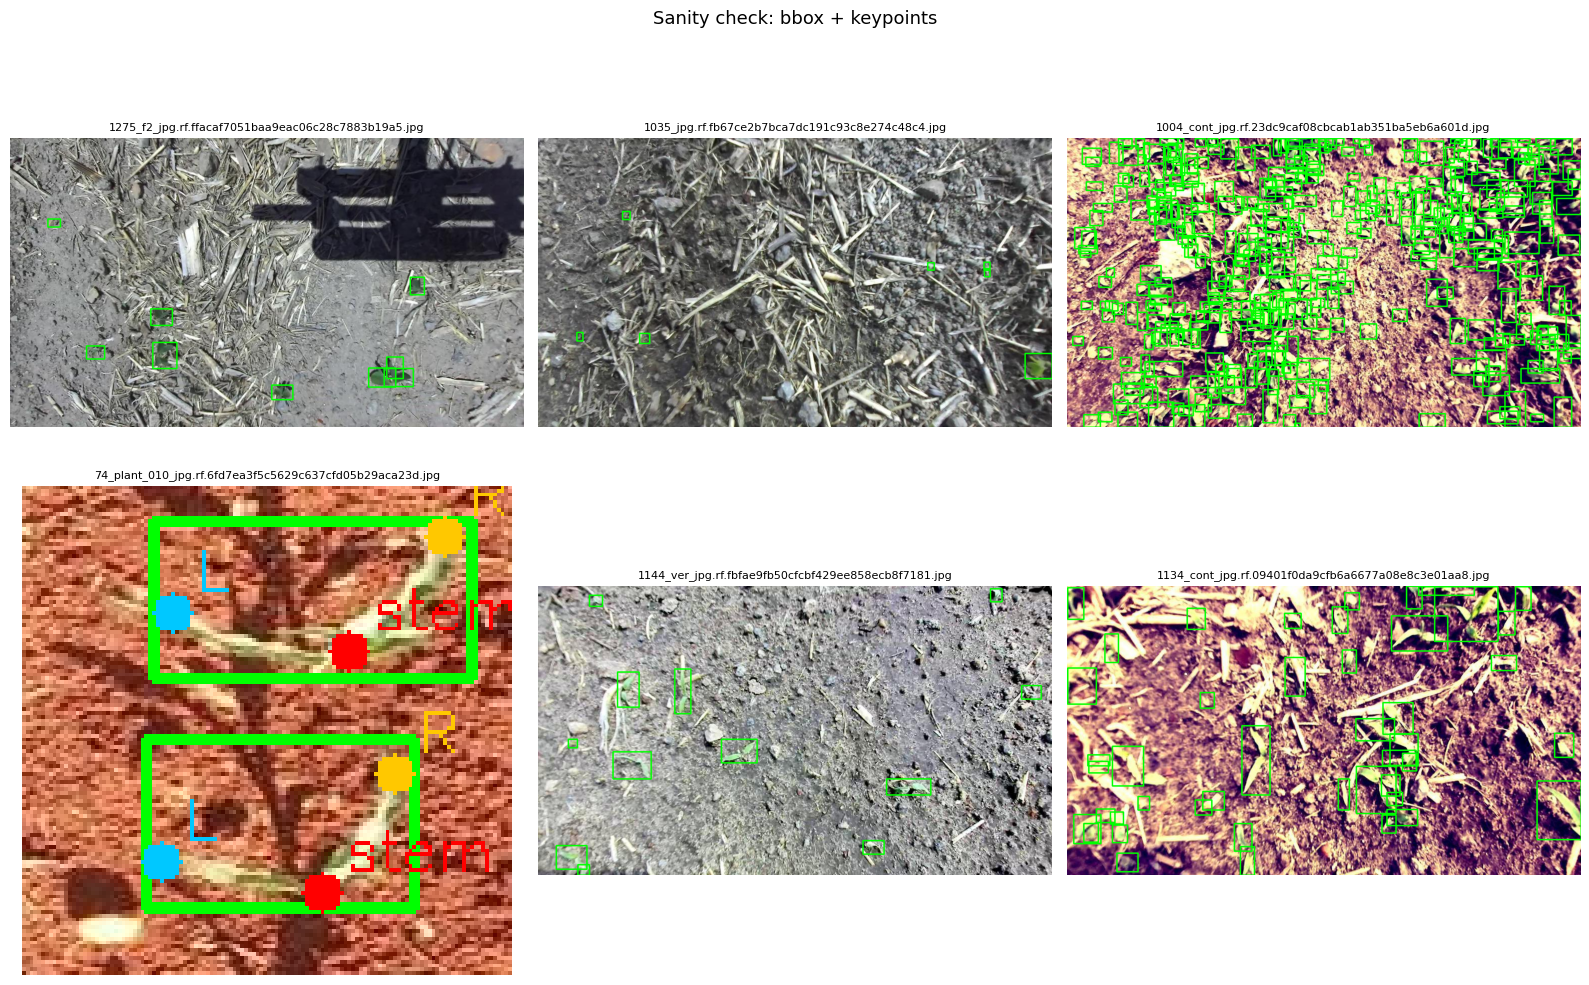

In [6]:
def draw_annotation(img, label_path):
    """
    Takes an image and its label file, and returns a copy of the image
    with the bounding box and keypoints drawn on top.
    Used for visual debugging only.
    """
    H, W = img.shape[:2]  # image height, width in pixels
    out = img.copy()      # don't modify the original

    # BGR colors (OpenCV convention) for each keypoint
    COLORS = {
        KP_STEM:  (255, 0, 0),    # red
        KP_LEFT:  (0, 200, 255),  # cyan-ish
        KP_RIGHT: (255, 200, 0),  # orange-ish
    }
    NAMES = {KP_STEM: 'stem', KP_LEFT: 'L', KP_RIGHT: 'R'}

    if not label_path.exists():
        return out  # no labels - just return the raw image

    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5 + NUM_KEYPOINTS * 3:
                continue

            # Convert normalized bbox [0,1] back to absolute pixels for drawing
            cx, cy, w, h = map(float, parts[1:5])
            x1 = int((cx - w/2) * W)
            y1 = int((cy - h/2) * H)
            x2 = int((cx + w/2) * W)
            y2 = int((cy + h/2) * H)
            cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)  # green bbox

            # Draw each keypoint
            for i in range(NUM_KEYPOINTS):
                base = 5 + i * 3
                kx = float(parts[base]) * W      # denormalize x
                ky = float(parts[base + 1]) * H  # denormalize y
                v = float(parts[base + 2])       # visibility flag
                if v > 0:  # only draw if actually annotated
                    cv2.circle(out, (int(kx), int(ky)), 5, COLORS[i], -1)
                    cv2.putText(out, NAMES[i], (int(kx) + 6, int(ky) - 6),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, COLORS[i], 1)
    return out


# Pick 6 random training images to spot-check
train_imgs = sorted((DATASET_ROOT / 'train' / 'images').iterdir())
sample = random.sample(train_imgs, min(6, len(train_imgs)))

# Set up a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, img_path in zip(axes.ravel(), sample):
    # OpenCV loads images as BGR; matplotlib expects RGB - convert
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    lbl = DATASET_ROOT / 'train' / 'labels' / (img_path.stem + '.txt')
    ax.imshow(draw_annotation(img, lbl))
    ax.set_title(img_path.name, fontsize=8)
    ax.axis('off')
plt.suptitle("Sanity check: bbox + keypoints", fontsize=13)
plt.tight_layout()
plt.show()

---
# 3. YOLO Configuration File

## What is `data.yaml`?

YOLO reads training configuration from a small text file in YAML format. We tell it three critical things:

| Setting | What it means |
|---------|---------------|
| `path`, `train`, `val` | Where the images are |
| `kpt_shape: [3, 3]` | Each plant has 3 keypoints, each with 3 values (x, y, visibility) |
| `flip_idx: [0, 2, 1]` | When training flips an image horizontally, remap keypoints: stem stays (0), left becomes right (1->2) and right becomes left (2->1) |
| `names: ['corn', 'weed']` | We only have two classes - "corn" and "weed". Weeds are detected just to be differentiated from corn, without keypoint or angle calculations |

## Why `flip_idx` matters

Horizontal flipping is a free way to double the effective size of your dataset - a mirrored corn plant is still a valid corn plant. But if you flip the image without also swapping the L/R keypoint labels, the model sees what's visually a "left leaf" labeled as "right" - broken supervision. `flip_idx` tells YOLO to swap them automatically.

In [7]:
# Compose the config dictionary in Python first, then dump it to YAML
data_yaml_path = DATASET_ROOT / 'data.yaml'

data_cfg = {
    # Absolute path to the dataset root
    'path': str(DATASET_ROOT),
    # Relative paths to train and val image folders (YOLO finds the matching labels automatically)
    'train': 'train/images',
    'val':   'valid/images',
    # Optional test split - include only if it exists
    'test':  'test/images' if (DATASET_ROOT / 'test' / 'images').exists() else None,

    # Keypoint shape: [num_keypoints, num_values_per_keypoint]
    # 3 keypoints, each with (x, y, visibility) = 3 values
    'kpt_shape': [NUM_KEYPOINTS, 3],

    # When horizontal flip augmentation triggers, this list says:
    # "keypoint index 0 becomes index 0 (stem - unchanged)"
    # "keypoint index 1 becomes index 2 (left tip -> right tip)"
    # "keypoint index 2 becomes index 1 (right tip -> left tip)"
    'flip_idx':  [KP_STEM, KP_RIGHT, KP_LEFT],

    # Two classes
    'names': ['corn', 'weed'],
}

# Remove any entries where the value is None (dict comprehension - filters {k:v for ...})
data_cfg = {k: v for k, v in data_cfg.items() if v is not None}

# Write the YAML file
with open(data_yaml_path, 'w') as f:
    yaml.safe_dump(data_cfg, f, sort_keys=False)

# Print so you can see what's in it
print(open(data_yaml_path).read())

path: C:\Users\atpou\projects\T1_Corn_Alignment\dataset
train: train/images
val: valid/images
test: test/images
kpt_shape:
- 3
- 3
flip_idx:
- 0
- 1
- 2
names:
- corn
- weed



---
# 4. YOLO11-pose model Training

## What we're actually training

YOLO is a family of object detection neural networks. YOLO**-pose** variants extend this to also predict keypoints within each detected object - exactly what we need.

We start from a pre-trained model (weights downloaded automatically - trained by Ultralytics on the COCO dataset of 100K+ human pose images) and **fine-tune** it on our 500 corn images. This is transfer learning: the model already knows how to "look" at images and find objects; we're teaching it to specialize in finding corn.

## Why train two sizes

| Model | Params | Speed | Accuracy |
|-------|--------|-------|----------|
| YOLO11n-pose | 3M | Fast | Good |
| YOLO11s-pose | 10M | Slower | Better |

Nano is fast enough for real-time use on embedded hardware. Small is more accurate but ~3x larger. Training both lets us pick the right trade-off once we see how well each performs.

## Key training hyperparameters

| Parameter | Meaning |
|-----------|---------|
| `epochs=200` | Look at the whole dataset 200 times |
| `imgsz=640` | Resize every image to 640x640 before training |
| `batch=2` | Process 2 images at a time (lower if you run out of GPU memory) |
| `patience=40` | Stop early if validation score hasn't improved in 40 epochs (saves time) |
| `pose=30.0` | Weight the keypoint-accuracy loss heavily (default is 12) - keypoints matter more than bbox for us |

## 4.1 Weather-robust augmentation

### What is augmentation?

During training, YOLO randomly modifies each image before feeding it to the model: rotate it, change the colors, add random noise. This teaches the model to be invariant to these variations - it learns what "corn" looks like regardless of lighting, angle, etc.

### Why we use aggressive settings

The project brief calls out rain and sunshine as deployment concerns. We can't collect data in every weather condition, but we can simulate them via augmentation. Strong brightness and HSV jitter simulate sunlight direction and intensity. Random erasing simulates leaves partially occluding each other, rain streaks, or dirt on the camera.

In [8]:
# Augmentation parameters passed to YOLO's trainer.
# Values are stronger than defaults because our dataset is small and we want robustness.
AUG = dict(
    # Color jitter - simulates different sun angles / times of day
    hsv_h=0.02,        # hue shift (+/-2%) - small, otherwise plants stop looking green
    hsv_s=0.70,        # saturation (+/-70%) - strong, simulates overcast vs. direct sun
    hsv_v=0.50,        # brightness (+/-50%) - strong, simulates shadow vs. bright sun

    # Geometric jitter - simulates camera not being perfectly level/centered
    degrees=15,        # rotation up to +/-15 deg
    translate=0.10,    # translation up to +/-10% of image size
    scale=0.40,        # scale up to +/-40% - accounts for varying camera height
    shear=3,           # shear up to +/-3 deg - tiny warping
    perspective=0.0005,  # perspective distortion - very small

    # Flipping
    fliplr=0.5,        # 50% chance of horizontal flip (uses flip_idx to swap L/R keypoints)
    flipud=0.0,        # never vertical flip - top-down corn has a consistent orientation

    # Advanced augmentation
    mosaic=1.0,        # always combine 4 training images into one - excellent for small datasets
    mixup=0.10,        # 10% chance to blend two images - regularization
    erasing=0.30,      # 30% chance to erase a random rectangle - simulates occlusion
)
# Dictionary variable that gets unpacked into model.train(...) in the next cells.

## 4.2 Train YOLO11n-pose

This is the fast model (expect 1 hour of training on a decent GPU). Watch the output, you'll see training loss decreasing each epoch, and validation metrics (mAP50, pose mAP50) increasing. If training loss decreases but validation stays flat, the model is memorizing instead of learning - but the augmentation and early stopping should prevent that.

In [ ]:
from ultralytics import YOLO  # YOLO is the main class we use for training and inference

# Load the nano pose model with pre-trained weights.
# If 'yolo11n-pose.pt' isn't already downloaded, Ultralytics fetches it the first time.
model_n = YOLO('yolo11n-pose.pt')

# Kick off training.
# **AUG unpacks our augmentation dict into keyword arguments.
results_n = model_n.train(
    data=str(data_yaml_path),   # path to data.yaml we wrote in section 3
    epochs=200,                 # max training passes through the dataset
    imgsz=640,                  # input resolution
    batch=2,
    workers=2,                   # mini-batch size (reduce to 8 or 4 if you see CUDA OOM errors)
    patience=40,                # early-stop after 40 epochs of no improvement
    device=0,                   # GPU index (0 = first GPU)
    project=str(PROJECT_ROOT / 'runs'),  # where to save logs/weights
    name='yolo11n_pose_corn',   # subfolder name for this run
    exist_ok=True,              # overwrite if the run folder already exists
    pose=30.0,                  # keypoint regression loss weight (default 12)
    kobj=2.0,                   # keypoint objectness loss weight
    **AUG,                      # unpack augmentation settings
)
# When this finishes, you'll have weights at: runs/yolo11n_pose_corn/weights/best.pt

## 4.3 Train YOLO11s-pose

Same as above but with a larger model. It is around 2-3x slower to train. Skip this cell if you're short on time - nano is usually good enough.

In [ ]:
# Same approach, bigger model
#model_s = YOLO('yolo11s-pose.pt')
#results_s = model_s.train(
#    data=str(data_yaml_path),
#    epochs=200,
#    imgsz=640,
#    batch=16,                # if you hit out-of-memory errors, try batch=8
#    patience=40,
#    device=0,
#    project=str(PROJECT_ROOT / 'runs'),
#    name='yolo11s_pose_corn',
#    exist_ok=True,
#    pose=30.0,
#    kobj=2.0,
#    **AUG,
#)

---
# 5. Trained Model Evaluation
We look at two kinds of metrics:

## Detection-quality metrics (mAP)

**mAP = mean Average Precision**, it asks: "across all IoU thresholds (how much bbox overlap counts as a correct detection), how many plants did the model find correctly and at what confidence?"

- **mAP50** - lenient, counts a detection as correct if IoU >= 50%. Typical "works well" threshold: > 0.85.
- **mAP50-95** - strict, averages over IoU thresholds from 50% to 95%. Typical "works well": > 0.60.

Both exist for boxes and for keypoints. Keypoint mAP is more relevant for us since the downstream alignment math lives on the keypoints.

We will use validation mAP for YOLO to track the best model seen so far and save it as best.pt. That's what will evaluate further with Pixel error.

## Per-keypoint pixel error (direct, interpretable)

For each validation image, we run the model, match each prediction to its ground-truth by bounding-box overlap, and compute the pixel distance between predicted and actual keypoint locations. Averaging over all matched plants gives us interpretable numbers.

### What to look for

- **Stem error** should be the smallest - it's near the plant center, visually unambiguous.
- **Leaf tip errors** tend to be larger - leaves are thin, and exact "tip" can be ambiguous.
- **p95 (95th percentile)** tells you worst-case behavior. If median is 3 pixels but p95 is 40 pixels, you have rare catastrophic failures you should inspect.

As a rule of thumb: stem pixel error should be less than `POS_TOLERANCE_PX / 3` (we set `POS_TOLERANCE_PX = 30` in section 9, so aim for stem error < 10 pixels) to keep scoring noise small compared to real planting noise.

In [9]:
from pathlib import Path
from ultralytics import YOLO

PROJECT_ROOT = Path(r"C:\Users\atpou\projects\T1_Corn_Alignment")  # Change this to your project root folder
DATASET_ROOT = PROJECT_ROOT / 'dataset'
data_yaml_path = DATASET_ROOT / 'data.yaml'
RUNS_DIR = PROJECT_ROOT / 'runs'

# ------------------------------------------------------------------------------
# Compare EVERY trained model found under runs/*/weights/best.pt and pick a winner.
# We only care about two things for this project:
#   (1) how well it detects CORN  (corn-class detection mAP / precision / recall)
#   (2) how accurately it places the KEYPOINTS (pose mAP - drives all the angle math)
# Weed detection is not a goal in itself (weeds only exist to suppress false corn),
# so it is shown for reference but does NOT decide the winner.
# ------------------------------------------------------------------------------

CORN_CLASS = 0
WEED_CLASS = 1
class_names = {CORN_CLASS: "corn", WEED_CLASS: "weed"}

# Discover all trained checkpoints, keyed by run-folder name.
candidates = {p.parent.parent.name: p
              for p in sorted(RUNS_DIR.glob('*/weights/best.pt'))}
if not candidates:
    raise FileNotFoundError(f"No best.pt checkpoints found under {RUNS_DIR}")

print(f"Found {len(candidates)} model(s) to compare:")
for name in candidates:
    print(f"  * {name}")

# Evaluate each model on the validation set.
results = {}      # name -> metrics object
table   = {}      # name -> dict of the numbers we care about
for name, ckpt in candidates.items():
    print(f"\nEvaluating {name} ...")
    try:
        m = YOLO(str(ckpt)).val(data=str(data_yaml_path),
                                imgsz=512, conf=0.001, iou=0.6, plots=False)
        if getattr(m, 'pose', None) is None or not hasattr(m.pose, 'map'):
            print(f"  skipped - no pose metrics (is {name} a pose model?)")
            continue
        # corn-class detection numbers
        try:
            cp, cr, cap50, cap = m.box.class_result(CORN_CLASS)
        except Exception:
            cp = cr = cap50 = cap = float('nan')
        results[name] = m
        table[name] = dict(corn_P=cp, corn_R=cr, corn_mAP50=cap50, corn_mAP=cap,
                           pose_mAP50=m.pose.map50, pose_mAP=m.pose.map)
    except Exception as e:
        print(f"  skipped - evaluation failed ({e})")

if not results:
    raise RuntimeError("No usable pose models were evaluated.")

# -- Clear comparison table ----------------------------------------------------
print("\n" + "="*78)
print("MODEL COMPARISON  -  corn detection + keypoint (pose) accuracy")
print("="*78)
print(f"{'Model':<22} | {'corn mAP50':>10} | {'corn P':>7} | {'corn R':>7} | "
      f"{'pose mAP50':>10} | {'pose mAP':>8}")
print("-"*23 + "+" + "-"*12 + "+" + "-"*9 + "+" + "-"*9 + "+" + "-"*12 + "+" + "-"*10)
for name, t in table.items():
    print(f"{name:<22} | {t['corn_mAP50']:>10.3f} | {t['corn_P']:>7.3f} | "
          f"{t['corn_R']:>7.3f} | {t['pose_mAP50']:>10.3f} | {t['pose_mAP']:>8.3f}")
print("\n(corn mAP50 = corn detection quality;  pose mAP = keypoint localization quality)")

# -- Winner: rank by keypoint accuracy first, corn detection as tie-breaker ------
# Keypoint accuracy is primary because every leaf angle depends on it; corn
# detection mAP50 breaks near-ties. Adjust the key if you weight them differently.
def rank_key(name):
    t = table[name]
    return (round(t['pose_mAP'], 3), round(t['corn_mAP50'], 3))

ranked = sorted(table, key=rank_key, reverse=True)
best_name = ranked[0]
BEST = candidates[best_name]
metrics = results[best_name]

print("="*78)
print(f"WINNER: {best_name}")
print(f"  keypoint (pose) mAP50-95 : {table[best_name]['pose_mAP']:.3f}")
print(f"  corn detection mAP50     : {table[best_name]['corn_mAP50']:.3f}")
print(f"  checkpoint               : {BEST}")
print("="*78)

# `model`, `BEST`, `metrics` are now set to the winning model for the rest of the notebook.
model = YOLO(str(BEST))

Found 3 model(s) to compare:
  • yolo11n_pose_corn
  • yolo11s_pose_corn
  • yolo26s_pose_corn

Evaluating yolo11n_pose_corn ...
Ultralytics 8.4.41  Python-3.13.5 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX 1000 Ada Generation Laptop GPU, 6141MiB)
YOLO11n-pose summary (fused): 110 layers, 2,654,521 parameters, 0 gradients, 6.6 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 15.311.0 MB/s, size: 130.3 KB)
val: Scanning C:\Users\atpou\projects\T1_Corn_Alignment\dataset\valid\labels... 141 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 141/141 889.7it/s 0.2s4s
val: New cache created: C:\Users\atpou\projects\T1_Corn_Alignment\dataset\valid\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 7.1it/s 1.3s0.1ss
                   all        141       5691      0.863      0.848      0.861      0.554      0.482        0.5      0.496       0.47
                  corn        

In [10]:
def iou_xyxy(a, b):
    """
    Compute Intersection-over-Union between two axis-aligned bounding boxes.
    Each box is [x1, y1, x2, y2] (top-left and bottom-right corners).
    Returns a value in [0, 1]. Higher = more overlap = more likely the same object.
    """
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    # Intersection box
    ix1 = max(ax1, bx1); iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2); iy2 = min(ay2, by2)
    iw = max(0, ix2 - ix1); ih = max(0, iy2 - iy1)
    inter = iw * ih

    # Union = sum of areas - intersection
    ua = (ax2 - ax1) * (ay2 - ay1) + (bx2 - bx1) * (by2 - by1) - inter
    return inter / ua if ua > 0 else 0


# Accumulate per-keypoint pixel errors across the whole validation set
val_imgs = sorted((DATASET_ROOT / 'valid' / 'images').iterdir())
errors = {KP_STEM: [], KP_LEFT: [], KP_RIGHT: []}

for img_path in val_imgs:
    img = cv2.imread(str(img_path))
    H, W = img.shape[:2]

    # Load ground truth for this image
    lbl_path = DATASET_ROOT / 'valid' / 'labels' / (img_path.stem + '.txt')
    if not lbl_path.exists():
        continue

    # Parse GT boxes and keypoints (denormalize to pixels)
    gts = []
    with open(lbl_path) as f:
        for line in f:
            p = line.strip().split()
            if len(p) < 5 + NUM_KEYPOINTS * 3:
                continue
            cx, cy, w, h = map(float, p[1:5])
            box = [(cx - w/2) * W, (cy - h/2) * H, (cx + w/2) * W, (cy + h/2) * H]
            kps = []
            for i in range(NUM_KEYPOINTS):
                base = 5 + i * 3
                kps.append((float(p[base]) * W, float(p[base + 1]) * H, float(p[base + 2])))
            gts.append((box, kps))

    # Run the model
    preds = model.predict(str(img_path), conf=0.25, iou=0.5, verbose=False)[0]
    if preds.boxes is None or len(preds.boxes) == 0:
        continue  # no detections - all GTs are "missed"; skip for error calc

    pred_boxes = preds.boxes.xyxy.cpu().numpy()     # (N, 4) array of boxes in pixels
    pred_kps   = preds.keypoints.xy.cpu().numpy()   # (N, 3, 2) array of keypoints in pixels

    # For each GT plant, match to the predicted plant with highest IoU
    for gt_box, gt_kps in gts:
        ious = [iou_xyxy(gt_box, pb) for pb in pred_boxes]
        if not ious or max(ious) < 0.3:
            continue  # no prediction overlapped this GT enough - treat as missed
        best = int(np.argmax(ious))  # index of the best-matching prediction

        # For each keypoint, accumulate the pixel distance between GT and prediction
        for i in range(NUM_KEYPOINTS):
            gx, gy, gv = gt_kps[i]
            if gv == 0:
                continue  # GT didn't annotate this keypoint - skip
            px, py = pred_kps[best, i]
            errors[i].append(np.hypot(px - gx, py - gy))  # Euclidean distance

# Print summary
print(f"{'Keypoint':<14}{'mean px':>10}{'median px':>12}{'p95 px':>10}{'n':>8}")
for i, name in zip([KP_STEM, KP_LEFT, KP_RIGHT], ['stem', 'leaf-left', 'leaf-right']):
    e = np.array(errors[i])
    if len(e):
        print(f"{name:<14}{e.mean():>10.2f}{np.median(e):>12.2f}"
              f"{np.percentile(e, 95):>10.2f}{len(e):>8}")

Keypoint         mean px   median px    p95 px       n
stem               16.74        7.09     53.41      66
leaf-left          28.04       10.90     96.70      66
leaf-right         35.82        8.76    147.31      66


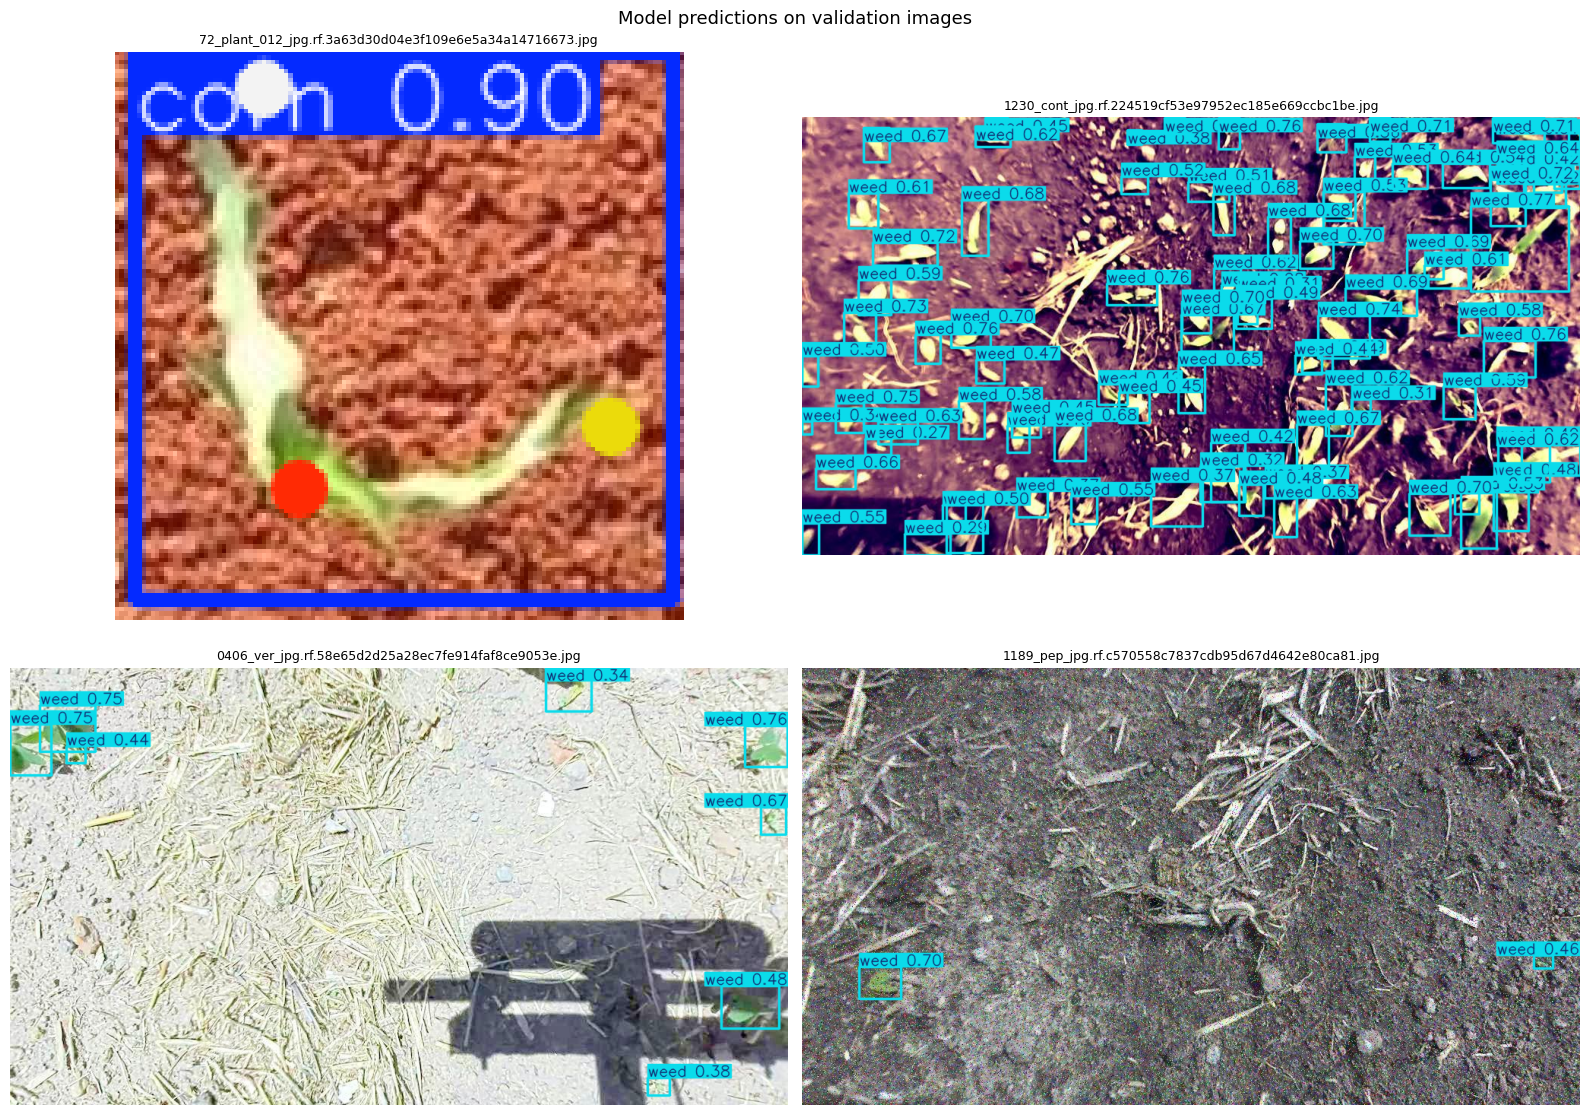

In [11]:
# --Sanity Check--
# Look at 4 random validation images with the model's predictions drawn on.

sample_val = random.sample(val_imgs, min(4, len(val_imgs)))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, img_path in zip(axes.ravel(), sample_val):
    # model.predict returns a Results object; [0] = results for image 0 (we pass one image)
    result = model.predict(str(img_path), conf=0.25, verbose=False)[0]
    # .plot() returns a numpy array with boxes + keypoints already drawn
    annotated = result.plot(kpt_radius=6, kpt_line=True)
    ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    ax.set_title(img_path.name, fontsize=9)
    ax.axis('off')
plt.suptitle("Model predictions on validation images", fontsize=13)
plt.tight_layout()
plt.show()

---
# 6. Inference Wrapper

The raw output of `model.predict()` is a complex object with tensors, confidence scores, etc. For the downstream code (row assignment, scoring), we want a simple list of dictionaries - one per plant - with named fields.

This cell defines a single function `detect_plants(image)` that returns a list like:

```python
[
    {
        'class_id':              0,                # 0 = corn, 1 = weed
        'bbox':                  [x1, y1, x2, y2], # in pixels
        'confidence':            0.94,             # how sure the model is (0 to 1)
        'stem':                  (450.2, 312.1),   # (x, y) or None if not confident
        'left_tip':              (420.0, 295.3),
        'right_tip':             (485.7, 301.8),
        'leaf_axis_deg':         12.5,             # angle of the line through both tips (undirected, -90..90]
        'left_leaf_angle_deg':   -170.0,           # directional angle of stem->left vector (-180..180]
        'right_leaf_angle_deg':  12.4,             # directional angle of stem->right vector (-180..180]
    },
    ...
]
```

The leaf-axis angle is *direction-agnostic* (a line, no arrow). The two per-leaf angles are *directional* vectors and complement the axis with information it can't carry - most usefully, whether the two leaves are growing in genuinely opposite directions (~180 deg apart) or whether something off has happened in the detection. This is the clean interface every later cell uses.


In [12]:
# Confidence threshold for keypoints: below this, we treat the keypoint as "missing"
# rather than trusting a low-confidence guess. Tune based on section 5.2 results.
KP_CONF_THRESHOLD = 0.3


def axis_angle_deg(p_left, p_right):
    """
    Compute the angle of the axis through the two leaf tips.
 
    Returns angle in degrees in the range (-90, 90]:
      0 deg   = horizontal (tips are left-right)
      90 deg  = vertical   (one tip above the other)
      -45 deg = diagonal down-right
 
    Why (-90, 90] instead of (-180, 180]? Because an axis (a line) has no direction.
    An axis at +170 deg and an axis at -10 deg describe the same line.
    We normalize so downstream code doesn't have to worry about equivalent angles.
    """
    if p_left is None or p_right is None:
        return None  # can't compute an axis if either tip is missing
 
    dx = p_right[0] - p_left[0]
    dy = p_right[1] - p_left[1]
    # arctan2 gives signed angle in (-180, 180]; np.degrees converts radians to degrees
    angle = np.degrees(np.arctan2(dy, dx))
 
    # Wrap into (-90, 90] - flip by 180 deg if outside that range (same line, opposite direction)
    while angle >   90: angle -= 180
    while angle <= -90: angle += 180
    return angle
 
 
def detect_plants(image_or_path, conf=0.25, iou=0.5):
    """
    Run the trained model on one image and return a list of plant dictionaries.
 
    Parameters
    ----------
    image_or_path : str or np.ndarray
        Path to an image file, or an image array already loaded with cv2.
    conf : float
        Minimum confidence to keep a detection (0 to 1). 0.25 = keep everything that's
        25%+ likely to be a plant. Lower catches more, but with more false positives.
    iou : float
        IoU threshold for non-max suppression (merging overlapping detections).
    """
    # Run inference; [0] because predict returns a list (one per input image)
    r = model.predict(image_or_path, conf=conf, iou=iou, verbose=False)[0]
    if r.boxes is None or len(r.boxes) == 0:
        return []  # no plants detected
 
    # Pull tensors off the GPU and convert to numpy arrays for convenience
    boxes   = r.boxes.xyxy.cpu().numpy()
    confs   = r.boxes.conf.cpu().numpy()
    classes = r.boxes.cls.cpu().numpy().astype(int)   # 0 = corn, 1 = weed
    kp_xy   = r.keypoints.xy.cpu().numpy()
    # Per-keypoint confidence isn't always exposed; fall back to 1.0 if unavailable
    try:
        kp_conf = r.keypoints.conf.cpu().numpy()  # (N, 3)
    except Exception:
        kp_conf = np.ones((len(boxes), NUM_KEYPOINTS))
 
    # Build our simple list of dictionaries
    plants = []
    for i in range(len(boxes)):
 
        def kp_or_none(idx):
            """Return keypoint (x,y) tuple or None if confidence is too low."""
            if kp_conf[i, idx] < KP_CONF_THRESHOLD:
                return None
            return (float(kp_xy[i, idx, 0]), float(kp_xy[i, idx, 1]))
 
        stem  = kp_or_none(KP_STEM)
        left  = kp_or_none(KP_LEFT)
        right = kp_or_none(KP_RIGHT)
 
        # Per-leaf directional angles: vector from stem to each leaf tip.
        # Range (-180, 180]. Image coordinates (y increases downward), so
        # 0 deg points right, +90 deg down, -90 deg up, +/-180 deg left.
        # These complement leaf_axis_deg (which is direction-agnostic).
        if stem is not None and left is not None:
            left_leaf_angle_deg = float(np.degrees(np.arctan2(
                left[1] - stem[1], left[0] - stem[0])))
        else:
            left_leaf_angle_deg = None
 
        if stem is not None and right is not None:
            right_leaf_angle_deg = float(np.degrees(np.arctan2(
                right[1] - stem[1], right[0] - stem[0])))
        else:
            right_leaf_angle_deg = None
 
        plants.append({
            'class_id':             int(classes[i]),
            'bbox':                 boxes[i].tolist(),
            'confidence':           float(confs[i]),
            'stem':                 stem,
            'left_tip':             left,
            'right_tip':            right,
            'leaf_axis_deg':        axis_angle_deg(left, right),
            'left_leaf_angle_deg':  left_leaf_angle_deg,
            'right_leaf_angle_deg': right_leaf_angle_deg,
        })
    return plants
 
 
# --- Quick demo ---
demo_path = random.choice(val_imgs)
plants = detect_plants(str(demo_path))
print(f"Detected {len(plants)} plants in {demo_path.name}")
# Print the first 3 plants to confirm the structure
for p in plants[:3]:
    print(f"  conf={p['confidence']:.2f}  stem={p['stem']}  "
          f"axis={p['leaf_axis_deg']}  "
          f"L={p['left_leaf_angle_deg']}  R={p['right_leaf_angle_deg']}")
    
# -----------------------------------------------------------------------------
# SANITY CHECK - keypoint plausibility for CORN only.
# Weeds carry no keypoints by design (they exist only to suppress false-positive
# corn), so their stem/tips are correctly None and are not checked here.
# -----------------------------------------------------------------------------
corn = [p for p in plants if p['class_id'] == 0]
print(f"\nDetected {len(plants)} objects "
      f"({len(corn)} corn, {len(plants) - len(corn)} weed) in {demo_path.name}.")

if not corn:
    print("No corn detected in this image - nothing to sanity-check "
          "(weeds carry no keypoints). Try another demo image.")
else:
    print("Per-corn keypoint sanity:")
    for j, p in enumerate(corn):
        flags = []
        if p['stem'] is None:       flags.append("no stem")
        if p['left_tip'] is None:   flags.append("no L tip")
        if p['right_tip'] is None:  flags.append("no R tip")
        if p['stem'] and p['left_tip'] and p['right_tip']:
            mx = (p['left_tip'][0] + p['right_tip'][0]) / 2
            my = (p['left_tip'][1] + p['right_tip'][1]) / 2
            span = np.hypot(p['left_tip'][0]-p['right_tip'][0],
                            p['left_tip'][1]-p['right_tip'][1])
            off = np.hypot(p['stem'][0]-mx, p['stem'][1]-my)
            if span > 0 and off > span:
                flags.append(f"stem far from tip-midpoint ({off:.0f}px vs span {span:.0f}px)")
        status = "OK" if not flags else "CHECK: " + ", ".join(flags)
        print(f"  corn {j}: axis={p['leaf_axis_deg']}  "
              f"L={p['left_leaf_angle_deg']}  R={p['right_leaf_angle_deg']}  -> {status}")

Detected 1 plants in 60_plant_003_jpg.rf.924d2b1ef9882741c8a1b769e0ed2945.jpg
  conf=0.82  stem=(77.6772689819336, 107.65150451660156)  axis=-33.28210554009749  L=-146.45850027764422  R=-76.67868687702916

Detected 1 objects (1 corn, 0 weed) in 60_plant_003_jpg.rf.924d2b1ef9882741c8a1b769e0ed2945.jpg.
Per-corn keypoint sanity:
  corn 0: axis=-33.28210554009749  L=-146.45850027764422  R=-76.67868687702916  -> OK


---
# 7. Per-row Seeding Line Builder - for live camera input

## Deployment model

This notebook is the prototype for the deployed system: a downward-facing camera (mounted on a tractor, or held by an operator) moves along the seeding line, capturing video frames in real time. The pipeline produces per-plant scores and a running per-row score as the camera moves.

Compared to the offline / batch pipelines (`Corn_Alignment_Pipeline.ipynb and Corn_Alignment_Prototype.ipynb`), this version differs in Section 7 onwards in two important ways:

1. **Row identity is declared by the operator.** Pressing `R` during the demo advances to the next row; pressing `0`-`9` jumps to that row directly. In a real tractor integration this would come from the tractor's GPS or row counter.
2. **The optimal line is built up monotonically and then locked.** This is the key correctness requirement.

## The line-building strategy

A single video can contain hundreds of frames of the same plant. We need a strategy that:

- Doesn't refit the line on every frame (jittery, expensive, and meaningless when the same plant is detected 30 times in a row)
- Doesn't let a plant influence the line that judges it (or the line could shift toward outliers, hiding their badness)
- Gives every plant in a row a consistent reference line

The approach:

- **First plant in a row:** the line is a vertical line through that plant's stem. (One point alone can't fix an angle.)
- **2nd, 3rd, 4th, 5th plants:** as each new plant is committed, refit the line with a constrained near-vertical robust fit over all committed stems so far. The line gradually stabilizes.
- **After the 5th plant:** the line is **locked**. New plants in the same row are scored against it but do *not* update it.
- **Row switch (R):** state resets for the new row.

This ensures every plant is scored against a reference that didn't depend on it (or, for plants 1-5, didn't depend on it much - a worth-flagging caveat is that the first few plants in a row influence their own reference line).

## Plant identity across frames

The detector reports the same physical plant on many consecutive frames. We must commit each *physical* plant to the row's stem list only once. Heuristic:

- A new detection is the "same plant" as the active candidate if its stem is within ~80 px and its bounding box overlaps significantly with the candidate's last bounding box.
- A candidate is committed to the row's stem list once it hasn't been seen for several frames (default: 6 frames, ~0.2 s at 30 fps).

This is a lightweight tracker but it's sufficient for walking-pace camera motion where plants don't move and the camera moves smoothly.

In [29]:
# -----------------------------------------------------------------------------
# Per-row state and live optimal-line builder
# -----------------------------------------------------------------------------

from dataclasses import dataclass, field
from typing import Optional

# How many committed plants are needed before the row's line is locked.
ROW_LOCK_AFTER_N_PLANTS = 5

# A new detection is the same physical plant as the active candidate if its
# stem is within this distance (pixels) AND its bbox IoU exceeds the threshold.
TRACK_SAME_PLANT_PX  = 220.0
TRACK_SAME_PLANT_IOU = 0.15

TRACK_MATCH_PX = 260.0
MAX_MISSED_FRAMES = 18
COMMIT_LINE_Y_FRAC = 0.62
COMMIT_ZONE_PX = 160
ROW_LOCK_AFTER_N_PLANTS = 5

@dataclass
class PlantTrack:
    stem: tuple
    prev_y: float
    last_seen_frame: int
    missed_frames: int = 0
    committed: bool = False

@dataclass
class RowState:
    committed_stems: list = field(default_factory=list)
    active_tracks: list = field(default_factory=list)
    line: Optional['OptimalLine'] = None
    locked: bool = False
    status: str = "empty"


def _is_same_plant(detection, candidate):
    """
    Heuristic identity check. Same plant if stems are close AND bboxes overlap.
    Either alone is too loose; both together is robust for corn rows at
    walking-pace camera motion.
    """
    stem = detection.get('stem')
    if stem is None:
        return False

    # Stem proximity check
    dx = stem[0] - candidate.mean_xy[0]
    dy = stem[1] - candidate.mean_xy[1]
    if (dx * dx + dy * dy) ** 0.5 >= TRACK_SAME_PLANT_PX:
        return False

    # For moving-camera video, bbox IoU is unstable because the same plant moves
    # through the frame. Stem proximity is the main identity check.
    if TRACK_SAME_PLANT_IOU <= 0:
        return True
    if candidate.last_bbox is None:
        return True
    return iou_xyxy(detection['bbox'], candidate.last_bbox) >= TRACK_SAME_PLANT_IOU


def _refit_row_line(row_state, frame_shape, prior_angle_deg=90.0):
    """Recompute row_state.line from the committed stems."""
    H, W = frame_shape[:2]
    stems = row_state.committed_stems
    n = len(stems)

    if n == 0:
        row_state.line = OptimalLine.from_point_angle(W / 2, H / 2, prior_angle_deg)
        row_state.status = "prior (no plants yet)"
        return

    if n == 1:
        # One stem: vertical through it (1 point can't determine an angle).
        x, y = stems[0]
        row_state.line = OptimalLine.from_point_angle(x, y, prior_angle_deg)
        row_state.status = f"vertical through plant 1 (1/{ROW_LOCK_AFTER_N_PLANTS})"
        return

    # 2+ stems: near-vertical robust fit, matching the field-photo pipeline.
    try:
        row_state.line = OptimalLine.from_points_near_vertical(
            stems, max_tilt_from_vertical_deg=15
        )
        if n >= ROW_LOCK_AFTER_N_PLANTS:
            row_state.locked = True
            row_state.status = f"locked ({n} plants)"
        else:
            row_state.status = f"near-vertical fit ({n}/{ROW_LOCK_AFTER_N_PLANTS})"
    except Exception:
        row_state.status = f"fit failed (kept previous, {n} plants)"


def update_row_state_from_frame(row_state, plants, frame_idx, frame_shape):
    H, W = frame_shape[:2]
    commit_y = COMMIT_LINE_Y_FRAC * H

    visible = [p for p in plants if p.get('stem') is not None]

    if row_state.line is None:
        _refit_row_line(row_state, frame_shape)

    # Mark all existing tracks as missed until matched.
    for tr in row_state.active_tracks:
        tr.missed_frames += 1

    unmatched = visible[:]

    # Greedy nearest-neighbor matching: detections -> existing tracks.
    for tr in row_state.active_tracks:
        if not unmatched:
            break

        best = min(
            unmatched,
            key=lambda p: np.hypot(p['stem'][0] - tr.stem[0],
                                   p['stem'][1] - tr.stem[1])
        )
        dist = np.hypot(best['stem'][0] - tr.stem[0],
                        best['stem'][1] - tr.stem[1])

        if dist <= TRACK_MATCH_PX:
            tr.prev_y = tr.stem[1]
            tr.stem = best['stem']
            tr.last_seen_frame = frame_idx
            tr.missed_frames = 0
            unmatched.remove(best)

    # New tracks for detections that did not match existing tracks.
    for p in unmatched:
        x, y = p['stem']
        row_state.active_tracks.append(
            PlantTrack(
                stem=p['stem'],
                prev_y=y,
                last_seen_frame=frame_idx
            )
        )

    # Commit each track once when it crosses or reaches the commit band.
    for tr in row_state.active_tracks:
        if tr.committed or row_state.locked:
            continue

        y = tr.stem[1]
        crossed_line = tr.prev_y < commit_y <= y
        inside_band = abs(y - commit_y) <= COMMIT_ZONE_PX

        if crossed_line or inside_band:
            row_state.committed_stems.append(tr.stem)
            tr.committed = True
            _refit_row_line(row_state, frame_shape)

    # Keep committed tracks alive briefly so the same plant is not re-created
    # immediately after crossing the line.
    row_state.active_tracks = [
        tr for tr in row_state.active_tracks
        if tr.missed_frames <= MAX_MISSED_FRAMES
    ]


def get_row_line(row_state):
    """Return the row's current optimal line and a status string for display."""
    return row_state.line, row_state.status

---
# 8. Optimal Seeding Line per Row Calculation

In our greenhouse trial, the seeds were deliberately hand-planted along straight perpendicular lines. So the iptimal line is the row they were supposed to land on, and we're measuring how far the plants drifted from it.

## Two ways to supply the optimal line

1. **If we know exactly where the rows were planted** (e.g., from the physical layout or a marking line in the image): use `OptimalLine.from_point_angle()` and hard-code the values. This is the most accurate.

2. **If we don't**: fit a line through the detected stems in each row using the **near-vertical robust fit**. This keeps the reference line close to the camera/tractor's expected row direction while still allowing a small lean. Implausible diagonal lines are avoided, so badly placed plants are scored as deviations instead of rotating the reference line.

In [25]:
from dataclasses import dataclass
from sklearn.linear_model import RANSACRegressor

def angular_diff_deg(a, b):
    """
    Smallest unsigned difference between two axis angles, normalized to [0, 90].

    Because an axis has no direction (line, not arrow), 170 deg and -10 deg describe
    the same axis, and their difference should be 0.
    """
    if a is None or b is None:
        return None
    d = abs(a - b) % 180
    return min(d, 180 - d)

def directional_angle_diff_deg(a, b):
    """
    Smallest *directional* difference between two vectors, in degrees, in [0, 180].

    Unlike angular_diff_deg (which wraps mod 180 and treats opposite directions as
    equal), this wraps mod 360, so a vector and its 180-deg opposite differ by 180.
    Used for the per-leaf deviations (report eqs. IV.7 / IV.8), which are directional.
    """
    if a is None or b is None:
        return None
    return abs((a - b + 180) % 360 - 180)

@dataclass
class OptimalLine:
    """
    Represents a line in image coordinates as a point + unit direction vector.

    Why store it this way instead of slope + intercept? Because slope-intercept
    breaks down for vertical lines (infinite slope). Point + direction works for
    any line orientation.

    Attributes
    ----------
    px, py : float
        A point on the line, in image pixels.
    dx, dy : float
        The direction vector of the line (unit length: dx*dx + dy*dy = 1).
    """
    px: float
    py: float
    dx: float
    dy: float

    @classmethod
    def from_point_angle(cls, px, py, angle_deg):
        """Construct a line from a point and an angle in degrees."""
        t = np.radians(angle_deg)
        return cls(px, py, np.cos(t), np.sin(t))

    @classmethod
    def from_ransac(cls, stems_xy, residual_threshold=15.0, random_state=SEED):
        """
        Fit a line to a cloud of stem (x, y) points using RANSAC.

        residual_threshold (in pixels) = how far from the line a point can be
        while still counting as an inlier. Set this to your planting tolerance.
        """
        stems = np.asarray(stems_xy)
        if len(stems) < 2:
            # Degenerate - only one point; return a horizontal line through it
            return cls(stems[0, 0], stems[0, 1], 1.0, 0.0)

        X, y = stems[:, 0:1], stems[:, 1]

        # Detect near-vertical rows and handle them separately.
        # A near-vertical row has very little x-spread - fitting y(x) is unstable.
        # We fit x(y) instead and then flip the result back.
        if X.std() < y.std() * 0.2:
            # Near-vertical case: regress x on y
            ry = RANSACRegressor(residual_threshold=residual_threshold,
                                 random_state=random_state).fit(stems[:, 1:2], stems[:, 0])
            m = ry.estimator_.coef_[0]     # slope of x = m*y + c
            c = ry.estimator_.intercept_   # intercept
            n = np.hypot(m, 1)              # magnitude for normalization
            # Direction vector (m, 1) normalized; passes through (c, 0)
            return cls(c, 0.0, m / n, 1.0 / n)
        else:
            # Normal case: regress y on x
            rx = RANSACRegressor(residual_threshold=residual_threshold,
                                 random_state=random_state).fit(X, y)
            m = rx.estimator_.coef_[0]      # slope of y = m*x + c
            c = rx.estimator_.intercept_
            n = np.hypot(1, m)
            # Direction vector (1, m) normalized; passes through (0, c)
            return cls(0.0, c, 1.0 / n, m / n)

    @classmethod
    def from_points_tls(cls, points):
        """
        Total-least-squares line through ALL given points (no outlier rejection).

        Unlike from_ransac, this uses *every* plant in the row to decide the line:
        the direction is the principal eigenvector of the centered stem cloud, and
        the line passes through the centroid. This is the right choice when we want
        the seeding line to account for all plants in the row (both the carefully
        planted control rows and the scattered experiment rows), rather than
        following an inlier majority and discarding the rest.
        """
        P = np.asarray(points, dtype=float)
        if len(P) < 2:
            return cls(P[0, 0], P[0, 1], 1.0, 0.0)
        centroid = P.mean(axis=0)
        cov = np.cov((P - centroid).T)
        evals, evecs = np.linalg.eigh(cov)
        d = evecs[:, -1]                       # largest-eigenvalue dir = line direction
        norm = np.hypot(d[0], d[1]) or 1.0
        return cls(centroid[0], centroid[1], d[0] / norm, d[1] / norm)

    def perpendicular_distance(self, pt):
        """
        Signed perpendicular distance from a point to the line, in pixels.

        Uses the 2D cross-product formula:
          distance = (pt - P) x direction
        where x is the scalar cross product (positive = left of line, negative = right).

        We usually take the absolute value for scoring.
        """
        vx, vy = pt[0] - self.px, pt[1] - self.py
        return vx * self.dy - vy * self.dx
    
    @classmethod
    def from_points_near_vertical(cls, points, max_tilt_from_vertical_deg=15):
        """
        Fit a row line that is allowed to lean slightly, but is constrained to stay
        near vertical in the image.

        This avoids the bad TLS behavior where unrelated cross-photo y placement
        rotates the row line diagonally.
        """
        P = np.asarray(points, dtype=float)
        P = P[np.isfinite(P).all(axis=1)]

        if len(P) == 0:
            raise ValueError("Cannot fit a row line with no valid stem points.")

        median_x = float(np.median(P[:, 0]))
        median_y = float(np.median(P[:, 1]))

        if len(P) < 3:
            return cls.from_point_angle(median_x, median_y, 90)

        y = P[:, 1]
        x = P[:, 0]

        # Robust slope estimate for x = a*y + b.
        slopes = []
        for i in range(len(P)):
            for j in range(i + 1, len(P)):
                dy = y[j] - y[i]
                if abs(dy) < 1e-6:
                    continue
                slopes.append((x[j] - x[i]) / dy)

        if not slopes:
            return cls.from_point_angle(median_x, median_y, 90)

        a = float(np.median(slopes))

        max_a = np.tan(np.radians(max_tilt_from_vertical_deg))
        a = float(np.clip(a, -max_a, max_a))

        b = float(np.median(x - a * y))

        # x = a*y + b has direction vector (a, 1).
        norm = np.hypot(a, 1.0)
        px = a * median_y + b
        py = median_y

        return cls(px, py, a / norm, 1.0 / norm)
    
    def angle_deg(self):
        """Return the angle of the line in degrees, normalized to (-90, 90]."""
        a = np.degrees(np.arctan2(self.dy, self.dx))
        while a >   90: a -= 180
        while a <= -90: a += 180
        return a


def fit_optimal_lines(plants, known_lines=None):
    """
    Build a dict mapping row_id -> OptimalLine.

    If no known line is provided, use the same near-vertical robust fit as the
    field-photo pipeline. This prevents arbitrary diagonal row lines when stem
    y-position is mostly camera framing/motion rather than true row geometry.
    """
    lines = {}

    rows = defaultdict(list)
    for p in plants:
        rid = p.get('row_id', 0)  # demo plants have no row_id yet; treat them as row 0
        if rid >= 0 and p.get('stem') is not None:
            rows[rid].append(p['stem'])

    for rid, stems in rows.items():
        if known_lines and rid in known_lines:
            px, py, a = known_lines[rid]
            lines[rid] = OptimalLine.from_point_angle(px, py, a)
        else:
            lines[rid] = OptimalLine.from_points_near_vertical(
                stems, max_tilt_from_vertical_deg=15
            )
    return lines


# --- Demo ---
optimal_lines = fit_optimal_lines(plants)
for rid, line in sorted(optimal_lines.items()):
    print(f"Row {rid}: angle={line.angle_deg():+.2f} deg  "
          f"passes through ({line.px:.0f}, {line.py:.0f})")


Row 0: angle=+90.00 deg  passes through (78, 108)


---
# 9. Alignment Scores and Deviations Computation

## Per-plant deviations

For every plant, we compute two numbers that feed the alignment score:

- **Positional deviation** - perpendicular pixel distance from the stem to its row's optimal line. Directly measures "how far off is this plant from where it was supposed to be?"
- **Angular deviation (axis-based)** - smallest unsigned angle between the plant's leaf axis (line through both tips) and the expected orientation. For our perpendicular trial, leaves should grow **across** the row, so the expected leaf axis is 90 deg off from the row direction. `EXPECTED_LEAF_OFFSET_DEG = 90 deg`. This is `ang_dev_deg` in the per-plant dict.

In addition, two **per-leaf directional deviations** are computed (`left_leaf_dev_deg` and `right_leaf_dev_deg`, report eqs. IV.7 / IV.8). Each is the directional angle between one leaf's vector (stem->tip) and its own expected perpendicular direction (the two expected directions are 180 deg apart, so the left leaf is expected to point one way and the right leaf the other). These are **descriptive only** - they do not feed `plant_score`. They are useful because a folded-back leaf reads a large outside angle (up to 180 deg), which distinguishes folding from a mild tilt that the axis-based metric can't separate.

## Per-plant score (0 to 100, higher = better)

We turn each scoring deviation into a sub-score in [0, 100]:

```
pos_score(d)     = 100 * exp(-d / POS_TOLERANCE_PX)              # exponential decay
ang_score(theta) = 100 * max(0, 1 - theta / ANG_TOLERANCE_DEG)   # linear decay, clamped at 0
plant_score      = 0.5 * pos_score + 0.5 * ang_score             # equal weighting
```

Why exponential decay for position? A plant 30 pixels off is bad, but a plant 60 pixels off isn't "twice as bad" - it's "qualitatively wrong." Exponential decay matches that intuition.

Why linear for angle? Because angle has a natural maximum (90 deg = completely perpendicular = 0 score makes sense), and pegging the score at 0 past the tolerance is the simplest defensible rule.

## Per-row score

Average the plant scores within each row. Also report the fraction of plants within tolerance - this is the number a farmer would actually care about: "85% of my plants in row 3 are within spec."

## Tuning knobs

The two constants below control how "strict" the scoring is. **Set these based on what a farmer considers acceptable planting error**, not what the model can achieve.


In [26]:
# --- Scoring thresholds - tune these based on real-world planting tolerance ---
POS_TOLERANCE_PX  = 30.0      # pixel offset at which positional score drops to ~37/100 (1/e)
ANG_TOLERANCE_DEG = 20.0      # angle offset at which angular score hits 0/100
EXPECTED_LEAF_OFFSET_DEG = 90.0  # leaves grow across (perpendicular to) the row

def score_plants(plants, optimal_lines,
                 pos_tol=POS_TOLERANCE_PX,
                 ang_tol=ANG_TOLERANCE_DEG,
                 expected_offset=EXPECTED_LEAF_OFFSET_DEG):
    """
    Add scoring fields to each plant dict:
      pos_dev_px, ang_dev_deg, pos_score, ang_score, plant_score
      left_leaf_dev_deg, right_leaf_dev_deg   (per-leaf deviation extension)
    """
    for p in plants:
        rid = p['row_id']
        # Can't score plants with no row assignment or no stem
        if rid < 0 or rid not in optimal_lines or p['stem'] is None:
            p.update(dict(pos_dev_px=None, ang_dev_deg=None,
                          pos_score=None, ang_score=None, plant_score=None,
                          left_leaf_dev_deg=None, right_leaf_dev_deg=None))
            continue
 
        line = optimal_lines[rid]
 
        # --- Positional deviation ---
        pos_dev = abs(line.perpendicular_distance(p['stem']))  # perpendicular distance, pixels
        p['pos_dev_px'] = pos_dev
        # Exponential decay: 100 at d=0, ~37 at d=pos_tol, ~14 at d=2*pos_tol
        p['pos_score']  = 100.0 * np.exp(-pos_dev / pos_tol)
 
        # --- Angular deviation (whole leaf axis vs expected) ---
        if p['leaf_axis_deg'] is not None:
            # Expected leaf axis = row direction + 90 deg (perpendicular)
            expected_axis_deg = line.angle_deg() + expected_offset
            # Normalize expected axis to (-90, 90]
            while expected_axis_deg >   90: expected_axis_deg -= 180
            while expected_axis_deg <= -90: expected_axis_deg += 180
 
            ang_dev = angular_diff_deg(p['leaf_axis_deg'], expected_axis_deg)
            p['ang_dev_deg'] = ang_dev
            # Linear decay: 100 at dev=0, 0 at dev=ang_tol, still 0 beyond
            p['ang_score']   = 100.0 * max(0.0, 1.0 - ang_dev / ang_tol)
        else:
            p['ang_dev_deg'] = None
            p['ang_score']   = None
 
        # --- Per-leaf deviations (report eqs. IV.7 / IV.8) ---
        # Angle of each leaf measured from ITS OWN expected perpendicular direction:
        # the left leaf vs the left perpendicular, the right leaf vs the right
        # perpendicular (the two are 180 deg apart, eqs. IV.5 / IV.6). We take the
        # magnitude of the signed difference (mod-360 wrap), so the value is the same
        # whether the leaf sits 10 deg above or 10 deg below the expected direction
        # (both -> 10), but a leaf FOLDED backward reads the large "outside" angle
        # (up to 180 deg), which distinguishes folding from a mild tilt.
        # Descriptive only; these do not feed plant_score.
        expected_left_leaf_deg  = line.angle_deg() + expected_offset          # IV.5
        expected_right_leaf_deg = expected_left_leaf_deg + 180                # IV.6
        if p.get('left_leaf_angle_deg') is not None:
            p['left_leaf_dev_deg']  = directional_angle_diff_deg(
                p['left_leaf_angle_deg'],  expected_left_leaf_deg)
        else:
            p['left_leaf_dev_deg']  = None
        if p.get('right_leaf_angle_deg') is not None:
            p['right_leaf_dev_deg'] = directional_angle_diff_deg(
                p['right_leaf_angle_deg'], expected_right_leaf_deg)
        else:
            p['right_leaf_dev_deg'] = None 
 
        # --- Combined score (unchanged from axis-only version) ---
        if p['ang_score'] is not None:
            p['plant_score'] = 0.5 * p['pos_score'] + 0.5 * p['ang_score']
        else:
            # If we couldn't compute angular (e.g., one leaf tip missing),
            # fall back to positional only
            p['plant_score'] = p['pos_score']
    return plants
 
 
def row_scores(plants):
    """
    Roll plant-level scores up to per-row summaries.
 
    For each row, returns:
      n              - number of plants
      mean_score     - average plant_score across the row
      mean_pos_px    - average positional deviation
      max_pos_px     - worst positional deviation (useful for spotting bad plants)
      mean_ang_deg   - average angular deviation
      within_tol_pct - fraction of plants within POS_TOLERANCE_PX
    """
    # Group plants by row
    rows = defaultdict(list)
    for p in plants:
        rid = p.get('row_id', 0)
        if rid >= 0 and p['plant_score'] is not None:
            rows[rid].append(p)
 
    summary = {}
    for rid, plist in rows.items():
        pos_devs = [p['pos_dev_px']  for p in plist if p['pos_dev_px']  is not None]
        ang_devs = [p['ang_dev_deg'] for p in plist if p['ang_dev_deg'] is not None]
        scores   = [p['plant_score'] for p in plist]
        within   = sum(1 for d in pos_devs if d <= POS_TOLERANCE_PX) / max(1, len(pos_devs))
 
        summary[rid] = dict(
            n=len(plist),
            mean_score=float(np.mean(scores)),
            mean_pos_px=float(np.mean(pos_devs)) if pos_devs else None,
            max_pos_px=float(np.max(pos_devs)) if pos_devs else None,
            mean_ang_deg=float(np.mean(ang_devs)) if ang_devs else None,
            within_tol_pct=100.0 * within,
        )
    return summary

# -----------------------------------------------------------------------------
# SANITY CHECK (geometry only - no model/photos needed). Confirms the per-leaf
# deviation = angle of each leaf from ITS expected perpendicular direction.
# Same value 10 deg above or below the expected line; a FOLDED-back leaf gives
# the large "outside" angle (up to 180). Range [0, 180].
# -----------------------------------------------------------------------------
print("="*64)
print("Per-leaf deviation = angle from the expected perpendicular direction")
print("="*64)
_perp = 0.0   # work in the expected perpendicular's own frame (its '0' line)
print(f"{'leaf vs expected':>18} {'deviation':>10}")
for _th in [0, 10, -10, 45, -45, 90, -90, 170, -170, 180]:
    print(f"{_th:>18} {directional_angle_diff_deg(_th, _perp):>10.1f}")
print("\nChecks:")
print("  +10 and -10 (tilt above/below) both ->",
      directional_angle_diff_deg(10,_perp), "/", directional_angle_diff_deg(-10,_perp))
print("  +170 / -170 (folded back) -> large outside angle:",
      directional_angle_diff_deg(170,_perp), "/", directional_angle_diff_deg(-170,_perp))


Per-leaf deviation = angle from the expected perpendicular direction
  leaf vs expected  deviation
                 0        0.0
                10       10.0
               -10       10.0
                45       45.0
               -45       45.0
                90       90.0
               -90       90.0
               170      170.0
              -170      170.0
               180      180.0

Checks:
  +10 and -10 (tilt above/below) both -> 10.0 / 10.0
  +170 / -170 (folded back) -> large outside angle: 170.0 / 170.0


---
# 10. Video-file alignment demo

## What this section does

This is the demonstration script that ties Section 1-Section 9 together. It reads a recorded `.mp4` of an operator walking down corn rows with a downward-facing camera, runs the trained model on every frame, tracks each plant across consecutive frames, fits the optimal seeding line for each row progressively as plants are committed, and scores every plant against the line. The output is a single annotated `.mp4` with bounding boxes, keypoints, the optimal line, and per-plant alignment scores burned in - plus a per-frame CSV log and a printed per-row summary.

## Inputs you set

Two values at the top of the cell:

- **`VIDEO_PATH`** - path to the input `.mp4` (default: `field_photos/walk.mp4`).
- **`ROW_SWITCH_TIMESTAMPS`** - a list of `"mm:ss"` strings marking when the operator switches rows. The first listed time becomes the boundary between row 0 and row 1, the second between row 1 and row 2, and so on. Leave the list empty (`[]`) to treat the whole video as a single row.

The timestamps replace the keyboard-driven row-switching from the original live-webcam version: since a recorded `.mp4` has no live operator pressing keys, you provide the row boundaries up front by watching the video once.

## What you see in the output video

- **White line** - the row's current optimal line; the reference all plants in that row are scored against.
- **White rings** - small circles at each *committed* stem (one per physical plant the tracker has confirmed across multiple frames). These are the points the near-vertical row fit is using.
- **Color-coded boxes** - green for high alignment score, fading through yellow to red for poor alignment. The leaf-axis line through the two leaf tips is drawn in the same color.
- **Magenta boxes** - detected weeds. Drawn for visibility, excluded from the row line fit and from the scoring (per Section 6 and Section 9).
- **HUD top-left** - playback time, current row index, counts of corn and weed detections in this frame, the line status (`prior`, `vertical (1/5)`, `fitting (N/5)`, or `locked`), and the row's running mean score.

In [31]:
import cv2
import csv
import bisect
from collections import defaultdict

# -- Config --------------------------------------------------------------------
VIDEO_PATH  = PROJECT_ROOT / "Video_Project_VeXtronics.mp4"            # input
OUT_VIDEO   = PROJECT_ROOT / "results" / "alignment_annotated.mp4"  # output video
OUT_CSV     = PROJECT_ROOT / "results" / "video_plants.csv"         # per-frame log
(PROJECT_ROOT / "results").mkdir(exist_ok=True)

CONF_THRESH = 0.15
IOU_THRESH  = 0.75
FRAME_LIMIT = None          # None = whole video; int = stop after N frames (debug)

# Row-switch timestamps as mm:ss strings. Empty list -> the whole video is row 0.
ROW_SWITCH_TIMESTAMPS = [
    "00:09", "00:26", "00:43", "00:56", "01:12"
]


# -- Drawing helpers -----------------------------------------------------------
def color_by_score(score):
    """Map a score in [0, 100] to a BGR color (red bad -> green good)."""
    if score is None:
        return (128, 128, 128)
    g = int(np.clip(score * 2.55, 0, 255))
    r = int(np.clip((100 - score) * 2.55, 0, 255))
    return (0, g, r)


def draw_optimal_line(frame, line):
    """Draw the row's optimal line all the way across the frame."""
    H, W = frame.shape[:2]
    t = max(H, W) * 2
    p1 = (int(line.px - t * line.dx), int(line.py - t * line.dy))
    p2 = (int(line.px + t * line.dx), int(line.py + t * line.dy))
    cv2.line(frame, p1, p2, (255, 255, 255), 2, cv2.LINE_AA)


def annotate_frame(frame, corn, weeds, line, committed_stems):
    """Draw optimal line, committed-stem rings, weeds (magenta), corn (scored)."""
    if line is not None:
        draw_optimal_line(frame, line)

    # Already-committed stems: small white rings, so a viewer can see what
    # the line is being fit to.
    for sx, sy in committed_stems:
        cv2.circle(frame, (int(sx), int(sy)), 8, (255, 255, 255), 2)

    # Weeds: drawn for transparency, but NOT scored (per the agreed design).
    for w in weeds:
        x1, y1, x2, y2 = map(int, w['bbox'])
        cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 255), 1)
        cv2.putText(frame, "weed", (x1, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 255), 1, cv2.LINE_AA)

    # Corn: bbox + stem + leaf axis + score, all colored by alignment score.
    for p in corn:
        score = p.get('plant_score')
        color = color_by_score(score)
        x1, y1, x2, y2 = map(int, p['bbox'])
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        if p['stem']:
            cv2.circle(frame, (int(p['stem'][0]), int(p['stem'][1])), 5, color, -1)
        if p['left_tip'] and p['right_tip']:
            lx, ly = map(int, p['left_tip']); rx, ry = map(int, p['right_tip'])
            cv2.line(frame, (lx, ly), (rx, ry), color, 2, cv2.LINE_AA)
        labels = []
        if score is not None:                 
            labels.append(f"score: {score:.0f}")
        if p.get('pos_dev_px')  is not None:  
            labels.append(f"pos: {p['pos_dev_px']:.0f}px")
        if p.get('ang_dev_deg') is not None:  
            labels.append(f"axis: {p['ang_dev_deg']:.0f}deg")
        if p.get('left_leaf_dev_deg') is not None:
            labels.append(f"L dev: {p['left_leaf_dev_deg']:.0f}deg")
        if p.get('right_leaf_dev_deg') is not None:
            labels.append(f"R dev: {p['right_leaf_dev_deg']:.0f}deg")
        if p.get('left_leaf_angle_deg') is not None:
            labels.append(f"L angle: {p['left_leaf_angle_deg']:.0f}deg")
        if p.get('right_leaf_angle_deg') is not None:
            labels.append(f"R angle: {p['right_leaf_angle_deg']:.0f}deg")
        for i, txt in enumerate(labels):
            cv2.putText(frame, txt, (x1, y1 - 8 - i * 18),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2, cv2.LINE_AA)


def draw_hud(frame, n_corn, n_weeds, current_row, line_status,
             row_running_score, n_committed, frame_idx, total_frames, fps):
    """Translucent strip in the top-left showing the current state."""
    overlay = frame.copy()
    cv2.rectangle(overlay, (0, 0), (640, 110), (0, 0, 0), -1)
    cv2.addWeighted(overlay, 0.5, frame, 0.5, 0, frame)

    t_sec = frame_idx / fps if fps else 0
    t_str = f"{int(t_sec // 60):02d}:{int(t_sec % 60):02d}"
    progress = f"{frame_idx}/{total_frames}" if total_frames else f"{frame_idx}"

    cv2.putText(frame,
                f"{t_str}  Row: {current_row}  Corn: {n_corn}  Weeds: {n_weeds}  Frame: {progress}",
                (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 2)
    cv2.putText(frame, f"Line: {line_status}  ({n_committed} committed)",
                (10, 58), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 255), 1)
    if row_running_score is not None:
        cv2.putText(frame, f"Row {current_row} mean score: {row_running_score:.1f}",
                    (10, 88), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)


# -- Helper: convert mm:ss timestamps to frame indices ------------------------
def mmss_to_frame(ts, fps):
    parts = ts.strip().split(":")
    if len(parts) == 2:
        sec = int(parts[0]) * 60 + float(parts[1])
    elif len(parts) == 3:
        sec = int(parts[0]) * 3600 + int(parts[1]) * 60 + float(parts[2])
    else:
        raise ValueError(f"Bad timestamp {ts!r}; use mm:ss")
    return int(round(sec * fps))


# -- Open input + output video ------------------------------------------------
if not VIDEO_PATH.exists():
    raise FileNotFoundError(f"Video not found: {VIDEO_PATH}")

cap = cv2.VideoCapture(str(VIDEO_PATH))
if not cap.isOpened():
    raise RuntimeError(f"OpenCV failed to open: {VIDEO_PATH}")

fps          = cap.get(cv2.CAP_PROP_FPS) or 29.84
W            = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H            = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
boundaries   = sorted(mmss_to_frame(t, fps) for t in ROW_SWITCH_TIMESTAMPS)

print(f"Input:  {VIDEO_PATH.name}  {W}x{H}  {fps:.2f} fps  ~{total_frames} frames")
print(f"Rows:   {len(boundaries) + 1}  (boundaries at frames {boundaries or 'none'})")

# 'mp4v' is the most portable codec (no extra installs). If your player won't
# open the file, try fourcc 'avc1' (H.264) or switch OUT_VIDEO to .avi + 'XVID'.
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(OUT_VIDEO), fourcc, fps, (W, H))
if not writer.isOpened():
    raise RuntimeError(
        f"VideoWriter failed to open {OUT_VIDEO}. "
        "Try fourcc 'avc1' or write to .avi with 'XVID'."
    )

# -- Per-frame CSV log --------------------------------------------------------
csv_file   = open(OUT_CSV, "w", newline="")
csv_writer = csv.writer(csv_file)
csv_writer.writerow(["frame_idx", "time", "row_id", "plant_idx_in_frame",
                     "class", "stem_x", "stem_y", "leaf_axis_deg",
                     "left_leaf_angle_deg", "right_leaf_angle_deg",
                     "pos_dev_px", "ang_dev_deg", "plant_score",
                     "left_leaf_dev_deg", "right_leaf_dev_deg",
                     "line_status", "n_committed"])

# -- State ---------------------------------------------------------------------
row_states    = defaultdict(RowState)      # row_id -> RowState (from Sec 7)
row_score_log = defaultdict(list)          # row_id -> list of scores (HUD + summary)
prev_row      = None
frame_idx     = 0

print("Processing ...")
try:
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_idx += 1
        if FRAME_LIMIT and frame_idx > FRAME_LIMIT:
            break

        # -- Row assignment ----------------------------------------------------
        # bisect_right(boundaries, f) = number of boundaries already passed,
        # which equals the row index.
        current_row = bisect.bisect_right(boundaries, frame_idx)

        # On a row switch, commit the OLD row's pending candidate so the last
        # plant of every row isn't dropped at the seam. (Same logic the
        # tracker normally applies after a 6-frame gap - we just force it.)
        if prev_row is not None and current_row != prev_row:
            row_states[prev_row].active_tracks.clear()
        prev_row = current_row

        # -- Inference ---------------------------------------------------------
        all_detections = detect_plants(frame, conf=CONF_THRESH, iou=IOU_THRESH)
        corn  = [p for p in all_detections if p['class_id'] == 0]
        weeds = [p for p in all_detections if p['class_id'] == 1]

        # -- Tracking, line, scoring (CORN only - weeds excluded by design) --
        update_row_state_from_frame(
            row_states[current_row], corn, frame_idx, frame.shape
        )
        line, status = get_row_line(row_states[current_row])
        for p in corn:
            p['row_id'] = current_row
        corn = score_plants(corn, {current_row: line})

        # Accumulate scores for the HUD running mean and the final summary.
        for p in corn:
            if p.get('plant_score') is not None:
                row_score_log[current_row].append(p['plant_score'])

        # -- CSV row per detection (corn + weeds) ----------------------------
        t_sec = frame_idx / fps
        t_str = f"{int(t_sec // 60):02d}:{int(t_sec % 60):02d}"
        n_committed = len(row_states[current_row].committed_stems)
        for idx, p in enumerate(corn + weeds):
            csv_writer.writerow([
                frame_idx, t_str, current_row, idx,
                'corn' if p['class_id'] == 0 else 'weed',
                f"{p['stem'][0]:.1f}" if p.get('stem') else '',
                f"{p['stem'][1]:.1f}" if p.get('stem') else '',
                f"{p['leaf_axis_deg']:.1f}" if p.get('leaf_axis_deg') is not None else '',
                f"{p['left_leaf_angle_deg']:.1f}"  if p.get('left_leaf_angle_deg')  is not None else '',
                f"{p['right_leaf_angle_deg']:.1f}" if p.get('right_leaf_angle_deg') is not None else '',
                f"{p['pos_dev_px']:.1f}"    if p.get('pos_dev_px')    is not None else '',
                f"{p['ang_dev_deg']:.1f}"   if p.get('ang_dev_deg')   is not None else '',
                f"{p['plant_score']:.1f}"   if p.get('plant_score')   is not None else '',
                f"{p['left_leaf_dev_deg']:.1f}"    if p.get('left_leaf_dev_deg')    is not None else '',
                f"{p['right_leaf_dev_deg']:.1f}"   if p.get('right_leaf_dev_deg')   is not None else '',
                status, n_committed,
            ])

        # -- Draw and write ---------------------------------------------------
        running = (np.mean(row_score_log[current_row])
                   if row_score_log[current_row] else None)
        annotate_frame(frame, corn, weeds, line,
                       row_states[current_row].committed_stems)
        draw_hud(frame, len(corn), len(weeds), current_row, status,
                 running, n_committed, frame_idx, total_frames, fps)
        writer.write(frame)

        # Progress every ~100 frames
        if frame_idx % 100 == 0:
            pct = (100 * frame_idx / total_frames) if total_frames else 0
            print(f"  frame {frame_idx}/{total_frames} ({pct:4.1f}%)  "
                  f"row {current_row}  {status}")

finally:
    cap.release()
    writer.release()
    csv_file.close()

# -- Session summary -----------------------------------------------------------
print()
print("=" * 70)
print("Video session summary")
print("=" * 70)
print(f"{'Row':>4}  {'committed':>10}  {'observations':>13}  {'mean score':>11}  status")
for rid in sorted(set(row_states) | set(row_score_log)):
    rs = row_states.get(rid)
    scores = row_score_log.get(rid, [])
    n_committed = len(rs.committed_stems) if rs else 0
    status = rs.status if rs else ''
    mean = f"{np.mean(scores):.1f}" if scores else ''
    print(f"{rid:>4}  {n_committed:>10}  {len(scores):>13}  {mean:>11}  {status}")
print(f"\nOutput video : {OUT_VIDEO}")
print(f"Output CSV   : {OUT_CSV}")


Input:  Video_Project_VeXtronics.mp4  1920x1080  30.00 fps  ~2615 frames
Rows:   6  (boundaries at frames [270, 780, 1290, 1680, 2160])
Processing ...
  frame 100/2615 ( 3.8%)  row 0  near-vertical fit (2/5)
  frame 200/2615 ( 7.6%)  row 0  near-vertical fit (3/5)
  frame 300/2615 (11.5%)  row 1  vertical through plant 1 (1/5)
  frame 400/2615 (15.3%)  row 1  near-vertical fit (2/5)
  frame 500/2615 (19.1%)  row 1  near-vertical fit (2/5)
  frame 600/2615 (22.9%)  row 1  near-vertical fit (2/5)
  frame 700/2615 (26.8%)  row 1  near-vertical fit (2/5)
  frame 800/2615 (30.6%)  row 2  prior (no plants yet)
  frame 900/2615 (34.4%)  row 2  vertical through plant 1 (1/5)
  frame 1000/2615 (38.2%)  row 2  near-vertical fit (3/5)
  frame 1100/2615 (42.1%)  row 2  near-vertical fit (3/5)
  frame 1200/2615 (45.9%)  row 2  near-vertical fit (3/5)
  frame 1300/2615 (49.7%)  row 3  prior (no plants yet)
  frame 1400/2615 (53.5%)  row 3  prior (no plants yet)
  frame 1500/2615 (57.4%)  row 3  prio

---
# 11. Closing notes - live demo specifics

## How each deliverable is addressed

| Deliverable | Where |
|-------------|-------|
| 1. Corn detection model | Section 4 trains `yolo11-pose`; Section 5 validates it |
| 2. Position + orientation per plant | Section 6 returns stem + leaf axis per plant |
| 3. Optimal growth line per row | Section 7 builds it per row, locked after 5 plants |
| 4. Deviation from optimal | Section 9 computes positional + angular deviation |
| 5. Plant and row alignment scores | Section 10 video-driven, with CSV export |

## Live-specific tuning knobs

| Knob | Cell | What it controls |
|------|------|------------------|
| `ROW_LOCK_AFTER_N_PLANTS` | Section 7 | How many plants must be committed before the row's line is frozen. Lower = locks faster; higher = more averaging before lockdown. |
| `TRACK_SAME_PLANT_PX` | Section 7 | Stem distance threshold for "same plant" across frames. Raise if camera moves fast. |
| `TRACK_SAME_PLANT_IOU` | Section 7 | Bbox-overlap threshold for "same plant." Raise to be stricter. |
| `CANDIDATE_COMMIT_AFTER_GAP_FRAMES` | Section 7 | How long a plant must be unseen before it counts as having exited the frame. |

## Caveats to mention if asked

- **The first plant in a row gets a vertical-line reference**, which assumes the camera is aligned with the row direction. Reasonable for top-down deployment but a known limitation.
- **Plants 1-5 in a row partially influence their own reference line.** After plant 6, the line is locked and later plants are judged against a reference that didn't depend on them.
- **Pixel-to-cm conversion is not yet calibrated.** All deviations are in pixels. Add a single `PX_PER_CM` constant once camera calibration is done.
- **Row identity is manual** (R key). In tractor deployment this would come from GPS / row-counter telemetry.

## Companion notebook

For offline batch analysis of a folder of field photos (no live camera), see `Corn_Alignment_Pipeline_2_4.ipynb`. It shares Section 1-Section 6 and Section 8-Section 9 with this notebook but replaces Section 7 and Section 10 with a folder-driven batch pipeline.